In [1]:
!pip install --user scipy==1.14.1 numpy==1.26.4 --force-reinstall -q
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124 -q
!pip install timm scikit-learn matplotlib tqdm -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
import os, sys, copy, math, time, json
from datetime import datetime
from typing import Dict, Any, Optional, Tuple, List
from itertools import cycle
from functools import partial

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.fft
from torch.utils.data import Dataset, DataLoader, random_split
import timm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Device: {device}")

PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA H200
Device: cuda


In [2]:
CONFIG = {
    "train_dir": "/home/jovyan/work/dataset/dataset/train",
    "val_dir": "/home/jovyan/work/dataset/dataset/val",
    "img_size": 150,
    "in_channels": 1,
    "num_classes": 3,
    "batch_size": 64,
    "num_workers": 4,
    "epochs": 150,
    "patience": 30,
    "lr": 5e-4,
    "weight_decay": 0.05,
    "warmup_epochs": 10,
    "label_smoothing": 0.1,
    "save_dir": "./checkpoints",
}


class NPYImageFolder(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.classes = sorted([d for d in os.listdir(root_dir)
                               if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for filename in os.listdir(class_dir):
                if filename.endswith('.npy'):
                    filepath = os.path.join(class_dir, filename)
                    self.samples.append((filepath, self.class_to_idx[class_name]))
        print(f"   Found {len(self.samples)} samples in {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        arr = np.load(filepath)
        if arr.ndim == 2:
            arr = arr[np.newaxis, :, :]
        elif arr.ndim == 3 and arr.shape[0] not in [1, 3]:
            arr = arr.transpose(2, 0, 1)
        if arr.max() > 1.0:
            arr = arr / 255.0
        tensor = torch.from_numpy(arr).float()
        if self.transform:
            tensor = self.transform(tensor)
        return tensor, label


class NPYTransform:
    def __init__(self, img_size, augment=False):
        self.img_size = img_size
        self.augment = augment

    def __call__(self, x):
        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                              mode='bilinear', align_corners=False).squeeze(0)
        if self.augment:
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-1])
            if torch.rand(1) > 0.5:
                x = torch.flip(x, dims=[-2])
            k = torch.randint(0, 4, (1,)).item()
            if k > 0:
                x = torch.rot90(x, k, dims=[-2, -1])
            if torch.rand(1) > 0.5:
                noise_std = torch.rand(1).item() * 0.05
                x = x + torch.randn_like(x) * noise_std
                x = torch.clamp(x, 0, 1)
            if torch.rand(1) > 0.5:
                brightness_factor = 0.8 + torch.rand(1).item() * 0.4
                x = torch.clamp(x * brightness_factor, 0, 1)
            if torch.rand(1) > 0.5:
                contrast_factor = 0.8 + torch.rand(1).item() * 0.4
                mean = x.mean()
                x = torch.clamp((x - mean) * contrast_factor + mean, 0, 1)
            if torch.rand(1) > 0.7:
                crop_ratio = 0.8 + torch.rand(1).item() * 0.15
                crop_size = int(self.img_size * crop_ratio)
                start = (self.img_size - crop_size) // 2
                x = x[:, start:start+crop_size, start:start+crop_size]
                x = F.interpolate(x.unsqueeze(0), size=(self.img_size, self.img_size),
                                  mode='bilinear', align_corners=False).squeeze(0)
        x = (x - 0.5) / 0.5
        return x


def get_dataloaders(config, test_split=0.15):
    train_transform = NPYTransform(config["img_size"], augment=True)
    val_transform = NPYTransform(config["img_size"], augment=False)
    train_dataset = NPYImageFolder(config["train_dir"], train_transform)
    val_full_dataset = NPYImageFolder(config["val_dir"], val_transform)
    total_val = len(val_full_dataset)
    test_size = int(total_val * test_split)
    val_size = total_val - test_size
    val_dataset, test_dataset = random_split(
        val_full_dataset, [val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"],
                              shuffle=True, num_workers=config["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"],
                            shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config["batch_size"],
                             shuffle=False, num_workers=config["num_workers"], pin_memory=True)
    return train_loader, val_loader, test_loader, train_dataset.classes


print("Loading NPY dataset...")
train_loader, val_loader, test_loader, classes = get_dataloaders(CONFIG)
print(f"\nData loaded:")
print(f"   Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}, Test: {len(test_loader.dataset)}")
print(f"   Classes: {classes}")
sample_batch, _ = next(iter(train_loader))
print(f"   Batch shape: {sample_batch.shape}")

Loading NPY dataset...
   Found 30000 samples in /home/jovyan/work/dataset/dataset/train
   Found 7500 samples in /home/jovyan/work/dataset/dataset/val

Data loaded:
   Train: 30000, Val: 6375, Test: 1125
   Classes: ['no', 'sphere', 'vort']
   Batch shape: torch.Size([64, 1, 150, 150])


In [3]:
class SpectralConv2d(nn.Module):
    """2D Fourier layer: FFT -> learned complex weights -> IFFT.
    Adapted from the 3D SpectralConv3d in ufno/ufno.py to operate on 2D spatial dims.
    Covers all 4 quadrants of the 2D frequency domain (low/high freq in each axis).
    """
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        B, C, H, W = x.shape
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(B, self.out_channels, H, W // 2 + 1,
                             dtype=torch.cfloat, device=x.device)

        m1 = min(self.modes1, H)
        m2 = min(self.modes2, W // 2 + 1)

        out_ft[:, :, :m1, :m2] = self.compl_mul2d(
            x_ft[:, :, :m1, :m2], self.weights1[:, :, :m1, :m2])
        out_ft[:, :, -m1:, :m2] = self.compl_mul2d(
            x_ft[:, :, -m1:, :m2], self.weights2[:, :, :m1, :m2])

        return torch.fft.irfft2(out_ft, s=(H, W))


class UNet2d(nn.Module):
    """2D U-Net branch for local feature extraction within UFNO layers.
    Adapted from the 3D U_net in ufno/ufno.py: 3-level encoder-decoder
    with skip connections via channel concatenation.
    """
    def __init__(self, channels, kernel_size=3, dropout_rate=0.1):
        super().__init__()
        self.conv1 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv2 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv2_1 = self._conv(channels, channels, kernel_size, stride=1, dropout_rate=dropout_rate)
        self.conv3 = self._conv(channels, channels, kernel_size, stride=2, dropout_rate=dropout_rate)
        self.conv3_1 = self._conv(channels, channels, kernel_size, stride=1, dropout_rate=dropout_rate)

        self.deconv2 = self._deconv(channels, channels)
        self.deconv1 = self._deconv(channels * 2, channels)
        self.deconv0 = self._deconv(channels * 2, channels)

        self.output_layer = nn.Conv2d(channels * 2, channels,
                                      kernel_size=kernel_size, stride=1,
                                      padding=(kernel_size - 1) // 2)

    def _conv(self, in_ch, out_ch, kernel_size, stride, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size,
                      stride=stride, padding=(kernel_size - 1) // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(dropout_rate),
        )

    def _deconv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
        )

    def forward(self, x):
        out_conv1 = self.conv1(x)
        out_conv2 = self.conv2_1(self.conv2(out_conv1))
        out_conv3 = self.conv3_1(self.conv3(out_conv2))
        out_deconv2 = self.deconv2(out_conv3)
        out_deconv2 = F.interpolate(out_deconv2, size=out_conv2.shape[-2:], mode='bilinear', align_corners=False)
        concat2 = torch.cat((out_conv2, out_deconv2), dim=1)
        out_deconv1 = self.deconv1(concat2)
        out_deconv1 = F.interpolate(out_deconv1, size=out_conv1.shape[-2:], mode='bilinear', align_corners=False)
        concat1 = torch.cat((out_conv1, out_deconv1), dim=1)
        out_deconv0 = self.deconv0(concat1)
        out_deconv0 = F.interpolate(out_deconv0, size=x.shape[-2:], mode='bilinear', align_corners=False)
        concat0 = torch.cat((x, out_deconv0), dim=1)
        return self.output_layer(concat0)

In [4]:
class UFNOEnhancedResNet(nn.Module):
    """ResNet-18 with a UFNO (U-shaped Fourier Neural Operator) spectral branch.

    Architecture mirrors ufno/ufno.py SimpleBlock3d:
      - Layers 0-1: pure Fourier (SpectralConv2d + 1x1 Conv)
      - Layers 2-3: hybrid Fourier + UNet2d (SpectralConv2d + 1x1 Conv + UNet2d)

    The UFNO branch runs in parallel with ResNet layers 2-4 after layer1,
    and features are fused via addition before the classifier.
    """
    def __init__(self, in_channels=1, num_classes=3, pretrained=True,
                 width=64, n_modes=(16, 16), unet_kernel_size=3, unet_dropout=0.1):
        super().__init__()
        backbone = timm.create_model('resnet18', pretrained=pretrained,
                                     in_chans=in_channels, num_classes=0)
        self.stem = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.act1, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.width = width
        modes1, modes2 = n_modes

        self.lift = nn.Conv2d(64, width, 1)

        self.spectral0 = SpectralConv2d(width, width, modes1, modes2)
        self.w0 = nn.Conv2d(width, width, 1)

        self.spectral1 = SpectralConv2d(width, width, modes1, modes2)
        self.w1 = nn.Conv2d(width, width, 1)

        self.spectral2 = SpectralConv2d(width, width, modes1, modes2)
        self.w2 = nn.Conv2d(width, width, 1)
        self.unet2 = UNet2d(width, unet_kernel_size, unet_dropout)

        self.spectral3 = SpectralConv2d(width, width, modes1, modes2)
        self.w3 = nn.Conv2d(width, width, 1)
        self.unet3 = UNet2d(width, unet_kernel_size, unet_dropout)

        self.norm0 = nn.BatchNorm2d(width)
        self.norm1 = nn.BatchNorm2d(width)
        self.norm2 = nn.BatchNorm2d(width)
        self.norm3 = nn.BatchNorm2d(width)

        self.spectral_proj = nn.Sequential(
            nn.Conv2d(width, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.GELU(),
            nn.Conv2d(256, 512, 3, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.GELU(),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)

        x_s = self.lift(x)

        x1 = self.spectral0(x_s)
        x2 = self.w0(x_s)
        x_s = self.norm0(F.gelu(x1 + x2))

        x1 = self.spectral1(x_s)
        x2 = self.w1(x_s)
        x_s = self.norm1(F.gelu(x1 + x2))

        x1 = self.spectral2(x_s)
        x2 = self.w2(x_s)
        x3 = self.unet2(x_s)
        x_s = self.norm2(F.gelu(x1 + x2 + x3))

        x1 = self.spectral3(x_s)
        x2 = self.w3(x_s)
        x3 = self.unet3(x_s)
        x_s = self.norm3(F.gelu(x1 + x2 + x3))

        x_spectral = self.spectral_proj(x_s)

        x_spatial = self.layer2(x)
        x_spatial = self.layer3(x_spatial)
        x_spatial = self.layer4(x_spatial)

        x_spectral = F.adaptive_avg_pool2d(x_spectral, x_spatial.shape[-2:])
        x = x_spatial + x_spectral

        x = self.pool(x).flatten(1)
        return self.classifier(x)


model = UFNOEnhancedResNet(
    in_channels=CONFIG["in_channels"],
    num_classes=CONFIG["num_classes"],
    pretrained=True,
    width=64,
    n_modes=(16, 16),
    unet_kernel_size=3,
    unet_dropout=0.1,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UFNO-Enhanced ResNet-18 — {total_params:,} total params, {trainable_params:,} trainable")

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

UFNO-Enhanced ResNet-18 — 22,305,923 total params, 22,305,923 trainable


In [5]:
class FocalCrossEntropyLoss(nn.Module):
    """Blended CrossEntropy (with label smoothing) + Focal Loss.
    CE handles the baseline well; focal loss downweights easy examples
    and focuses on hard class-boundary samples (subtle substructure differences).
    """
    def __init__(self, label_smoothing=0.1, gamma=2.0, alpha=0.7):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.gamma = gamma
        self.alpha = alpha

    def focal_loss(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

    def forward(self, logits, targets):
        return self.alpha * self.ce(logits, targets) + (1 - self.alpha) * self.focal_loss(logits, targets)


criterion = FocalCrossEntropyLoss(
    label_smoothing=CONFIG["label_smoothing"], gamma=2.0, alpha=0.7
)
print("Loss: FocalCrossEntropyLoss (0.7*CE_smooth + 0.3*Focal)")

Loss: FocalCrossEntropyLoss (0.7*CE_smooth + 0.3*Focal)


In [6]:
def plot_roc_curve(all_labels, all_probs, class_names, save_path="roc_curve.png"):
    all_labels_bin = label_binarize(all_labels, classes=range(len(class_names)))
    all_probs = np.array(all_probs)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(class_names))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(class_names)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(class_names)
    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(10, 8))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'micro-average (AUC = {roc_auc["micro"]:.4f})',
             color='deeppink', linestyle=':', linewidth=4)
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'macro-average (AUC = {roc_auc["macro"]:.4f})',
             color='navy', linestyle=':', linewidth=4)
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    for i, color in zip(range(len(class_names)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('UFNO-Enhanced ResNet-18 — ROC Curve', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right"); plt.grid(alpha=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"ROC curve saved to {save_path}")
    return roc_auc


def plot_training_history(history, title="Training History"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs = [h['epoch'] for h in history]

    axes[0].plot(epochs, [h['train_loss'] for h in history], label='Train')
    axes[0].plot(epochs, [h['val_loss'] for h in history], label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, [h['train_acc'] for h in history], label='Train')
    axes[1].plot(epochs, [h['val_acc'] for h in history], label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(epochs, [h['val_roc_auc'] for h in history], label='Val ROC-AUC',
                 color='green')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('ROC-AUC')
    axes[2].set_title('ROC-AUC'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG["save_dir"], f"history_{title.replace(' ', '_')}.png"),
                dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_on_test(model, test_loader, device, class_names, model_name="model"):
    model.eval()
    all_probs, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Testing {model_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total
    test_auc = roc_auc_score(np.array(all_labels), np.array(all_probs),
                             multi_class='ovr', average='macro')
    print(f"\n{model_name} — Test Results:")
    print(f"   Accuracy: {test_acc:.2f}%")
    print(f"   ROC-AUC (macro): {test_auc:.4f}")
    return test_acc, test_auc, all_probs, all_labels

In [7]:
def train_model(model, train_loader, val_loader, config, device, class_names,
                criterion, model_name="model"):
    num_epochs = config["epochs"]
    patience = config.get("patience", 30)
    save_dir = config["save_dir"]
    os.makedirs(save_dir, exist_ok=True)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=config.get("lr", 5e-4),
                                  weight_decay=config.get("weight_decay", 0.05))
    warmup_epochs = config.get("warmup_epochs", 10)
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer, start_factor=0.01, total_iters=warmup_epochs)
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs - warmup_epochs, eta_min=1e-6)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[warmup_epochs])

    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"   Params: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Epochs: {num_epochs}, Patience: {patience}")
    print(f"   LR: {config.get('lr', 5e-4)}, WD: {config.get('weight_decay', 0.05)}")
    print(f"   Loss: {criterion.__class__.__name__}")
    print(f"{'='*60}\n")

    model.to(device)
    best_roc_auc = 0.0
    best_val_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_probs, best_labels = [], []
    history = []

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}',
                              'acc': f'{100*train_correct/train_total:.1f}%'})
        scheduler.step()

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        all_probs, all_labels_list = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                all_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        train_loss /= train_total
        train_acc = 100 * train_correct / train_total
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        try:
            val_roc_auc = roc_auc_score(np.array(all_labels_list), np.array(all_probs),
                                        multi_class='ovr', average='macro')
        except ValueError:
            val_roc_auc = 0.0

        current_lr = scheduler.get_last_lr()[0]
        history.append({'epoch': epoch+1, 'train_loss': train_loss,
                        'train_acc': train_acc, 'val_loss': val_loss,
                        'val_acc': val_acc, 'val_roc_auc': val_roc_auc,
                        'lr': current_lr})

        improved = val_roc_auc > best_roc_auc
        if improved:
            best_roc_auc = val_roc_auc
            best_val_acc = val_acc
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            best_probs, best_labels = all_probs, all_labels_list
            torch.save({
                'model_state_dict': model.state_dict(),
                'val_roc_auc': best_roc_auc, 'val_acc': best_val_acc,
                'epoch': epoch+1, 'history': history,
            }, os.path.join(save_dir, f"best_{model_name}.pth"))
            status = "NEW BEST"
        else:
            epochs_no_improve += 1
            status = f"No improve ({epochs_no_improve}/{patience})"

        print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.6f} | {status}")
        print(f"  Train: loss={train_loss:.4f}, acc={train_acc:.2f}%")
        print(f"  Val:   loss={val_loss:.4f}, acc={val_acc:.2f}%, ROC-AUC={val_roc_auc:.4f}")
        print(f"  Best:  ROC-AUC={best_roc_auc:.4f}, acc={best_val_acc:.2f}%")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"Training Complete: {model_name}")
    print(f"   Best ROC AUC: {best_roc_auc:.4f}")
    print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"{'='*60}\n")

    model.load_state_dict(best_model_wts)
    if best_probs and best_labels:
        plot_roc_curve(best_labels, best_probs, class_names,
                       os.path.join(save_dir, f"roc_{model_name}.png"))

    return model, history, best_probs, best_labels


Training: UFNO_Enhanced_ResNet
   Params: 22,305,923
   Epochs: 150, Patience: 30
   LR: 0.0005, WD: 0.05
   Loss: FocalCrossEntropyLoss



Epoch 1/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/150 | LR: 0.000054 | NEW BEST
  Train: loss=0.9456, acc=33.98%
  Val:   loss=0.9222, acc=33.54%, ROC-AUC=0.5080
  Best:  ROC-AUC=0.5080, acc=33.54%


Epoch 2/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 144/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 144/150 | LR: 0.000003 | No improve (29/30)
  Train: loss=0.2713, acc=96.06%
  Val:   loss=0.2582, acc=97.33%, ROC-AUC=0.9945
  Best:  ROC-AUC=0.9954, acc=96.91%


Epoch 145/150 [Train]:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 145/150 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 145/150 | LR: 0.000003 | No improve (30/30)
  Train: loss=0.2712, acc=96.03%
  Val:   loss=0.2583, acc=97.35%, ROC-AUC=0.9945
  Best:  ROC-AUC=0.9954, acc=96.91%

Early stopping at epoch 145

Training Complete: UFNO_Enhanced_ResNet
   Best ROC AUC: 0.9954
   Best Val Accuracy: 96.91%



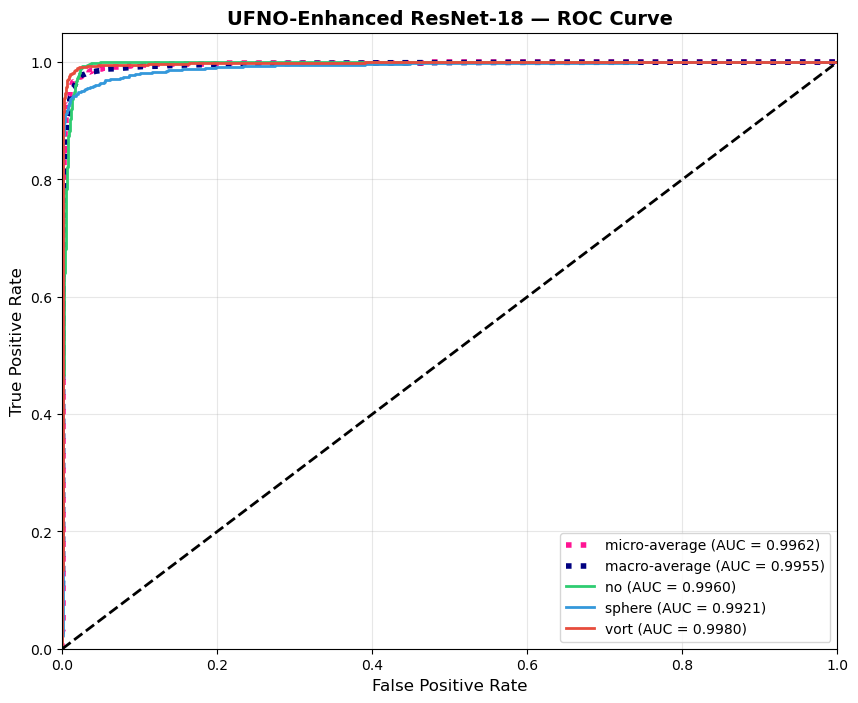

ROC curve saved to ./checkpoints/roc_UFNO_Enhanced_ResNet.png


In [8]:
model, history, best_probs, best_labels = train_model(
    model, train_loader, val_loader, CONFIG, device, classes,
    criterion=criterion,
    model_name="UFNO_Enhanced_ResNet"
)

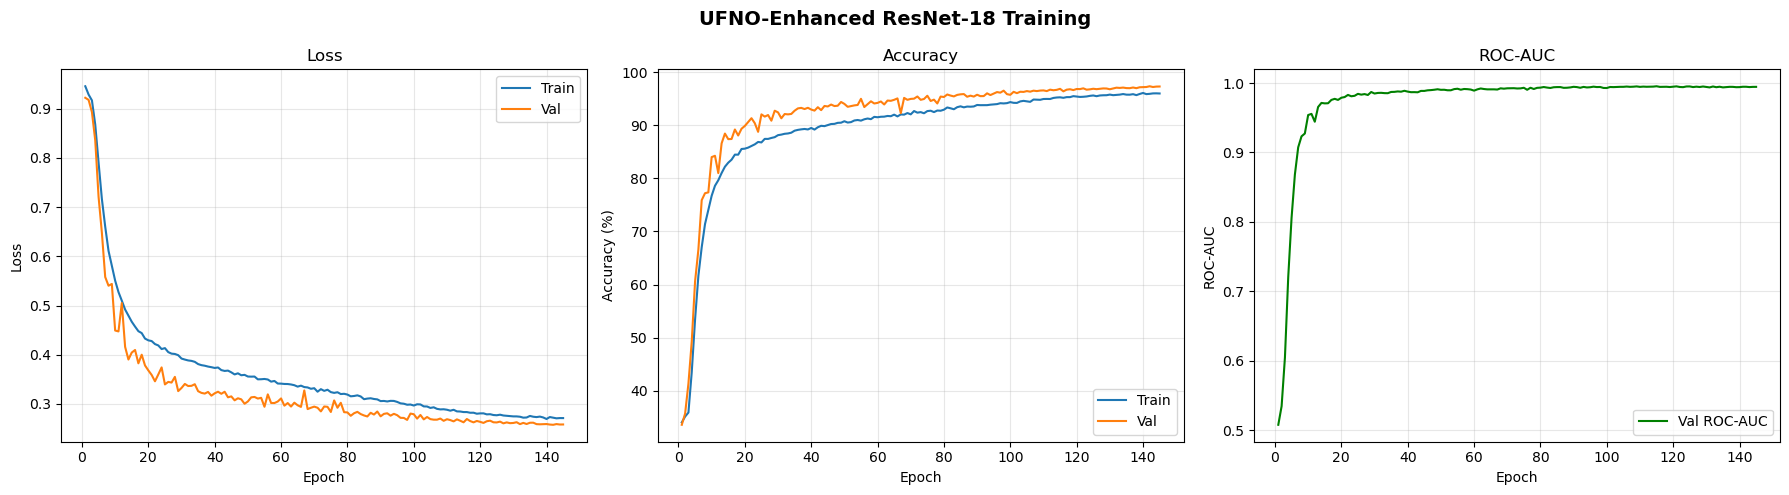

In [9]:
plot_training_history(history, title="UFNO-Enhanced ResNet-18 Training")

Testing UFNO-Enhanced ResNet-18:   0%|          | 0/18 [00:00<?, ?it/s]


UFNO-Enhanced ResNet-18 — Test Results:
   Accuracy: 96.44%
   ROC-AUC (macro): 0.9942


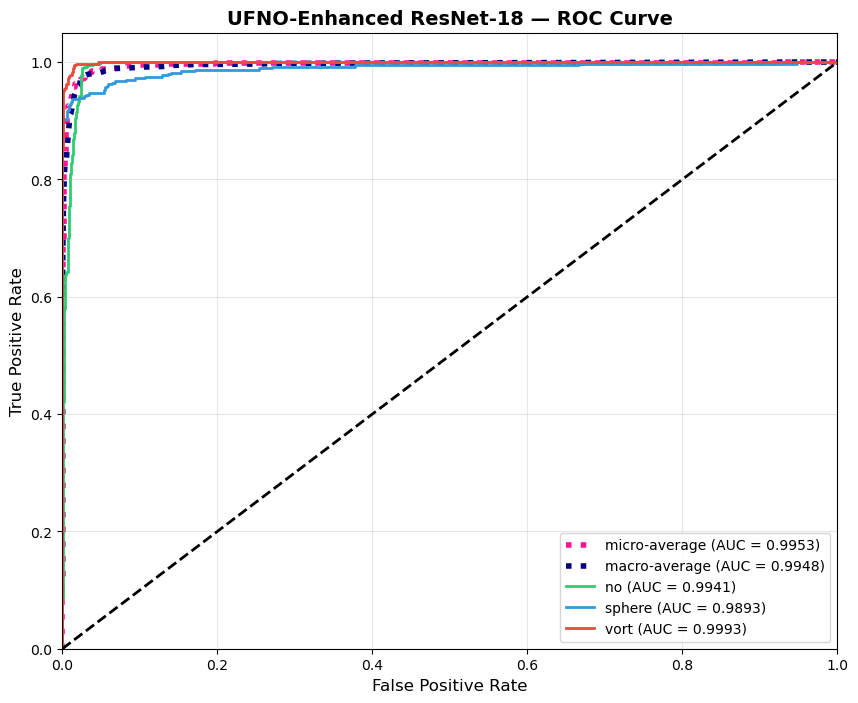

ROC curve saved to ./checkpoints/roc_test_UFNO_Enhanced_ResNet.png


{0: 0.9940531472961979,
 1: 0.98928308235654,
 2: 0.9993124401534951,
 'micro': 0.9952675555555555,
 'macro': 0.9948334522582365}

In [10]:
test_acc, test_auc, test_probs, test_labels = evaluate_on_test(
    model, test_loader, device, classes, "UFNO-Enhanced ResNet-18"
)

plot_roc_curve(test_labels, test_probs, classes,
               os.path.join(CONFIG["save_dir"], "roc_test_UFNO_Enhanced_ResNet.png"))

In [11]:
print("=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)
print(f"{'Model':<30} {'ROC-AUC (macro)':>15} {'Accuracy':>10}")
print("-" * 60)
print(f"{'FNO Classifier':<30} {'0.9717':>15} {'88.31%':>10}")
print(f"{'FNO-Enhanced ResNet':<30} {'0.9888':>15} {'93.54%':>10}")
print(f"{'UFNO-Enhanced ResNet (ours)':<30} {test_auc:>15.4f} {test_acc:>9.2f}%")
print("-" * 60)
print(f"{'Common Test I Baseline':<30} {'0.9882':>15} {'93.71%':>10}")
print("=" * 60)

RESULTS COMPARISON
Model                          ROC-AUC (macro)   Accuracy
------------------------------------------------------------
FNO Classifier                          0.9717     88.31%
FNO-Enhanced ResNet                     0.9888     93.54%
UFNO-Enhanced ResNet (ours)             0.9942     96.44%
------------------------------------------------------------
Common Test I Baseline                  0.9882     93.71%
